# ***Assignment 5: Image Generation and Latent Space Interpolation using a Pre-trained StyleGAN Model***


###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 27-09-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

## **Objectives**

1. Load a pretrained StyleGAN model.
2. Generate two random latent vectors, `z1` and `z2`.
3. Generate images corresponding to the two latent vectors.
4. Save the generated images.
5. Perform linear interpolation between `z1` and `z2`.
6. Generate approximately 10 intermediate latent vectors and images.
7. Create an image strip showing the smooth transition between the two generated images.
8. Generate the original two images again using the same latent vectors.
9. Compare the regenerated images with the original images.
10. Analyze the changes observed during latent-space interpolation.

## **Introduction to StyleGAN**

StyleGAN is a Generative Adversarial Network architecture developed for generating high-quality synthetic images.

It consists mainly of:

- A mapping network
- A synthesis network
- Latent space
- Learned styles

Instead of directly generating an image from random noise, StyleGAN transforms a latent vector into a representation that controls different visual characteristics of the generated image.

For this experiment, a pretrained StyleGAN2-ADA model trained on the FFHQ face dataset is used.

The latent vector is represented as:

\[
z \in \mathbb{R}^{512}
\]

Two random latent vectors, `z1` and `z2`, are generated and passed through the pretrained generator.

In [ ]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

%cd stylegan2-ada-pytorch

!pip install click requests tqdm pyspng ninja imageio-ffmpeg

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 3.38 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/stylegan2-ada-pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.2 MB/s eta 0:00:00


## **Step 1: Import Required Libraries**

The following libraries are required:

- PyTorch – for deep learning operations
- NumPy – for numerical operations
- Matplotlib – for displaying images
- PIL – for image processing
- OS – for creating directories and handling files

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

## **Step 2: Check GPU Availability**

StyleGAN is computationally expensive, so a GPU is preferred.

The following code checks whether CUDA/GPU is available.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. The model will run on CPU.")

Device: cuda
GPU: Tesla T4


## **Step 3: Download the Pretrained StyleGAN Model**

Instead of training StyleGAN from the beginning, a pretrained StyleGAN2-ADA model is loaded.

The FFHQ pretrained model is trained for generating human face images.

The pretrained model is downloaded as a `.pkl` file.

In [ ]:
import os
import requests

network_url = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"
network_path = "/content/stylegan2-ada-pytorch/ffhq.pkl"

if not os.path.exists(network_path):
    print("Downloading pretrained StyleGAN model...")

    response = requests.get(network_url, stream=True)

    with open(network_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print("Download completed.")
else:
    print("Model already exists.")

Download completed.


## **Step 4: Load the Pretrained StyleGAN Model**

The pretrained generator is loaded from the downloaded `.pkl` file.

The generator will be used to convert latent vectors into images.

In [ ]:
import legacy

with open(network_path, "rb") as f:
    network = legacy.load_network_pkl(f)

G = network["G_ema"].to(device)

G.eval()

print("StyleGAN model loaded successfully.")
print("Latent dimension:", G.z_dim)
print("Image resolution:", G.img_resolution)

StyleGAN model loaded successfully.
Latent dimension: 512
Image resolution: 1024


## **Step 5: Create an Output Directory**

All generated images will be stored inside an output directory.

The directory will contain:

- Original generated images
- Interpolated images
- Image strip
- Regenerated images

In [ ]:
output_dir = "/content/stylegan_assignment_results"

os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: /content/stylegan_assignment_results


## **Step 6: Generate Two Random Latent Vectors**

A latent vector is a numerical representation used by the generator to produce an image.

We generate two random latent vectors:

- `z1`
- `z2`

Each vector has 512 dimensions.

These two vectors will produce two different generated faces.

In [ ]:
torch.manual_seed(42)

z1 = torch.randn([1, G.z_dim], device=device)
z2 = torch.randn([1, G.z_dim], device=device)

print("Shape of z1:", z1.shape)
print("Shape of z2:", z2.shape)

Shape of z1: torch.Size([1, 512])
Shape of z2: torch.Size([1, 512])


## **Step 7: Generate Images Using z1 and z2**

The two latent vectors are passed through the pretrained StyleGAN generator.

The generator converts each latent vector into a synthetic face image.

Therefore:

\[
z_1 \rightarrow Image_1
\]

\[
z_2 \rightarrow Image_2
\]

In [ ]:
with torch.no_grad():
    image1 = G(
        z1,
        None,
        truncation_psi=0.7,
        noise_mode="const"
    )

    image2 = G(
        z2,
        None,
        truncation_psi=0.7,
        noise_mode="const"
    )

print("Images generated successfully.")
print("Image 1 shape:", image1.shape)
print("Image 2 shape:", image2.shape)

Setting up PyTorch plugin "bias_act_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py:50: UserWarning: Failed to build CUDA kernels for bias_act. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py", line 48, in _init
    _plugin = custom_ops.get_plugin('bias_act_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module 

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Images generated successfully.
Image 1 shape: torch.Size([1, 3, 1024, 1024])
Image 2 shape: torch.Size([1, 3, 1024, 1024])


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## **Step 8: Convert Generated Images for Display**

The StyleGAN output is represented as a tensor.

For displaying the image:

1. Move the tensor from GPU to CPU.
2. Convert the values into the range 0–255.
3. Convert the tensor into a NumPy array.
4. Convert it into an image format.

In [ ]:
def tensor_to_image(tensor):
    image = tensor[0].permute(1, 2, 0)
    image = (image * 127.5 + 128).clamp(0, 255)
    image = image.to(torch.uint8).cpu().numpy()
    return image

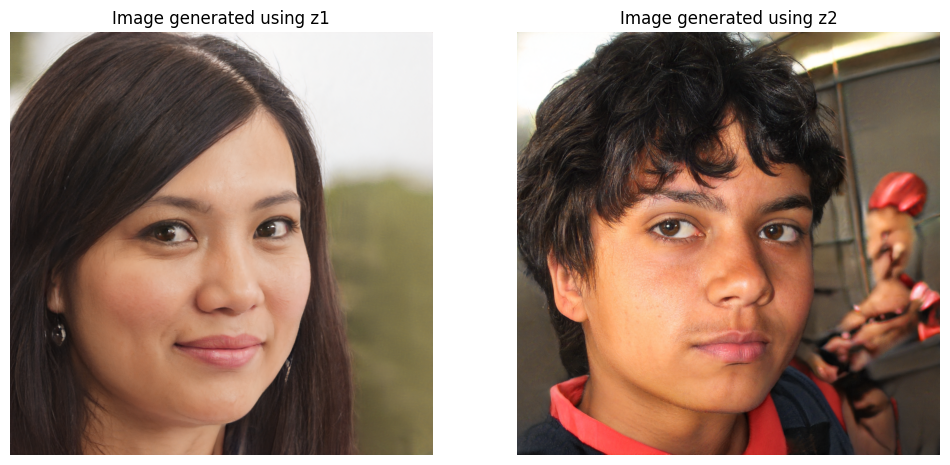

In [ ]:
img1 = tensor_to_image(image1)
img2 = tensor_to_image(image2)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Image generated using z1")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off")
plt.title("Image generated using z2")

plt.show()

## **Step 9: Save the Generated Images**

The two generated images are saved as:

- `image_z1.png`
- `image_z2.png`

Saving the images allows them to be compared later with the regenerated images.

In [ ]:
image1_path = os.path.join(output_dir, "image_z1.png")
image2_path = os.path.join(output_dir, "image_z2.png")

Image.fromarray(img1).save(image1_path)
Image.fromarray(img2).save(image2_path)

print("Image 1 saved:", image1_path)
print("Image 2 saved:", image2_path)

Image 1 saved: /content/stylegan_assignment_results/image_z1.png
Image 2 saved: /content/stylegan_assignment_results/image_z2.png


## **Step 10: Linear Interpolation Between z1 and z2**

Linear interpolation is used to move gradually from one latent vector to another.

The interpolation formula is:

\[
z(t) = (1-t)z_1 + tz_2
\]

where:

- `z1` = starting latent vector
- `z2` = ending latent vector
- `t` = interpolation value
- `0 ≤ t ≤ 1`

When:

\[
t = 0
\]

the vector is exactly `z1`.

When:

\[
t = 1
\]

the vector is exactly `z2`.

Values between 0 and 1 generate intermediate latent vectors.

Therefore, the generated face changes gradually from the first face to the second face.

## **Step 11: Generate Around 10 Intermediate Latent Vectors**

We generate 10 latent vectors between `z1` and `z2`.

The interpolation values are:

\[
0,\frac{1}{9},\frac{2}{9},...,\frac{8}{9},1
\]

Each interpolated latent vector is passed through the StyleGAN generator to produce an intermediate image.

In [ ]:
num_images = 10

alphas = torch.linspace(0, 1, num_images, device=device)

interpolated_latents = []

for alpha in alphas:
    z_interpolated = (1 - alpha) * z1 + alpha * z2
    interpolated_latents.append(z_interpolated)

print("Number of interpolated latent vectors:", len(interpolated_latents))

Number of interpolated latent vectors: 10


## **Step 12: Generate Intermediate Images**

Each interpolated latent vector is given to the StyleGAN generator.

This creates a sequence of images showing the transition from the first generated face to the second generated face.

In [ ]:
interpolated_images = []

with torch.no_grad():
    for z in interpolated_latents:
        generated = G(
            z,
            None,
            truncation_psi=0.7,
            noise_mode="const"
        )

        image = tensor_to_image(generated)
        interpolated_images.append(image)

print("Generated", len(interpolated_images), "intermediate images.")

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plu

...

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Generated 10 intermediate images.


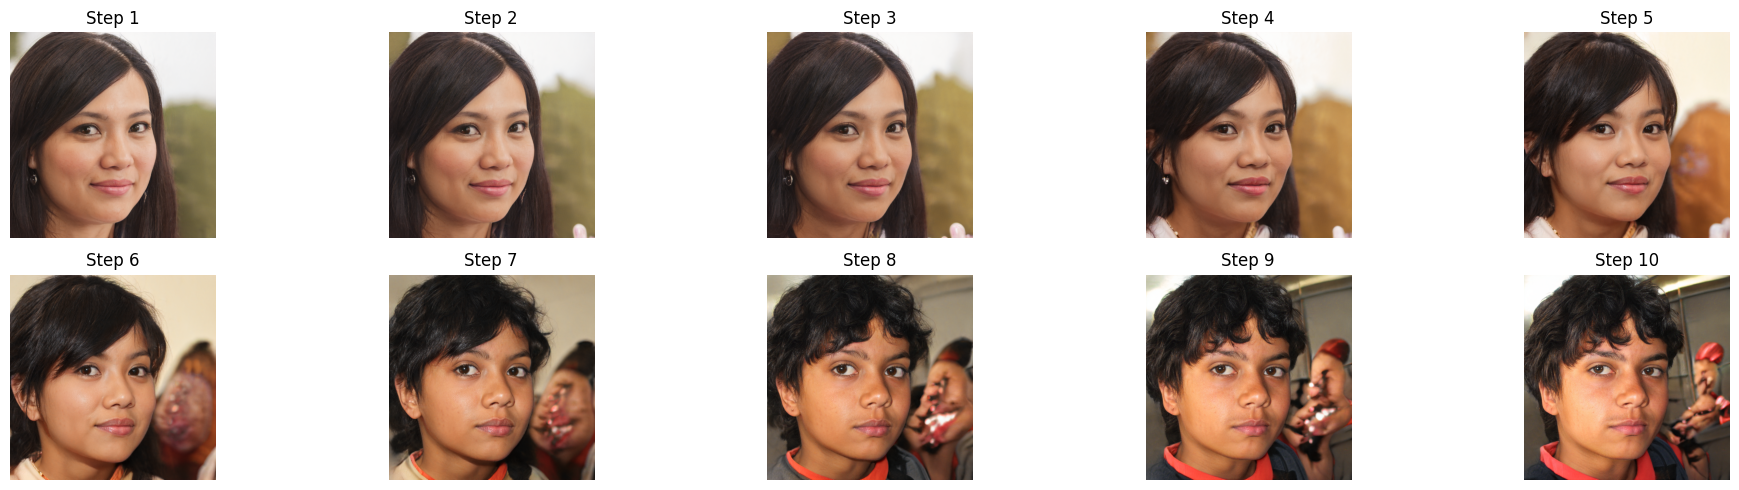

In [ ]:
plt.figure(figsize=(20, 5))

for i, image in enumerate(interpolated_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Step {i+1}")

plt.tight_layout()
plt.show()

**What you should observe**

The first image should resemble the image generated from z1.

The last image should resemble the image generated from z2.

The images in between should gradually change.

## **Step 13: Save the Intermediate Images**

The 10 intermediate images are saved individually.

These images can later be used to create a single image strip.

In [ ]:
intermediate_paths = []

for i, image in enumerate(interpolated_images):
    path = os.path.join(
        output_dir,
        f"intermediate_{i+1:02d}.png"
    )

    Image.fromarray(image).save(path)
    intermediate_paths.append(path)

print("All intermediate images saved.")

All intermediate images saved.


## **Step 14: Create a Single Image Strip**

An image strip is created by placing all the interpolated images next to each other.

The strip visually demonstrates the smooth transition between the two latent vectors.

The sequence represents:

\[
z_1 \rightarrow z_{intermediate} \rightarrow z_2
\]

In [ ]:
# Resize images for a compact strip
strip_size = 256

resized_images = []

for image in interpolated_images:
    pil_image = Image.fromarray(image)
    pil_image = pil_image.resize((strip_size, strip_size))
    resized_images.append(pil_image)

strip_width = strip_size * len(resized_images)
strip_height = strip_size

image_strip = Image.new(
    "RGB",
    (strip_width, strip_height)
)

for i, image in enumerate(resized_images):
    image_strip.paste(
        image,
        (i * strip_size, 0)
    )

strip_path = os.path.join(
    output_dir,
    "stylegan_interpolation_strip.png"
)

image_strip.save(strip_path)

print("Image strip saved at:")
print(strip_path)

Image strip saved at:
/content/stylegan_assignment_results/stylegan_interpolation_strip.png


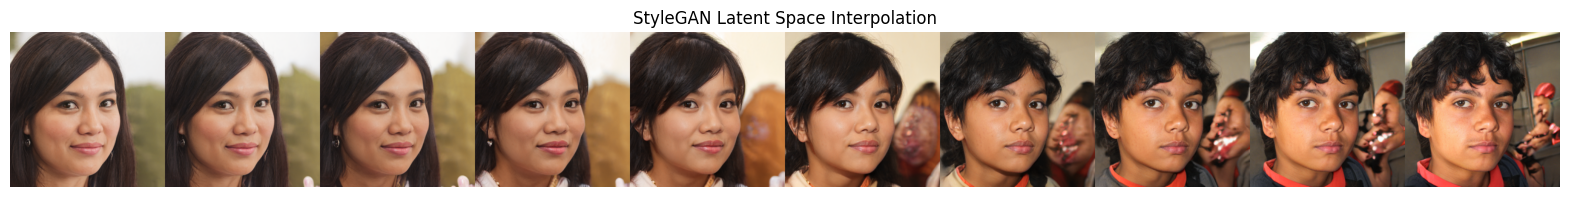

In [ ]:
plt.figure(figsize=(20, 3))

plt.imshow(image_strip)
plt.axis("off")
plt.title("StyleGAN Latent Space Interpolation")

plt.show()

## **Step 15: Generate the Images Again Using z1 and z2**

The same latent vectors `z1` and `z2` are passed through the StyleGAN generator again.

The newly generated images are compared with the original images.

Since the same latent vectors and deterministic noise mode are used, the regenerated images should be identical or extremely close to the original images.

In [ ]:
with torch.no_grad():
    regenerated_image1 = G(
        z1,
        None,
        truncation_psi=0.7,
        noise_mode="const"
    )

    regenerated_image2 = G(
        z2,
        None,
        truncation_psi=0.7,
        noise_mode="const"
    )

regenerated_img1 = tensor_to_image(regenerated_image1)
regenerated_img2 = tensor_to_image(regenerated_image2)

print("Images regenerated successfully.")

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Images regenerated successfully.


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

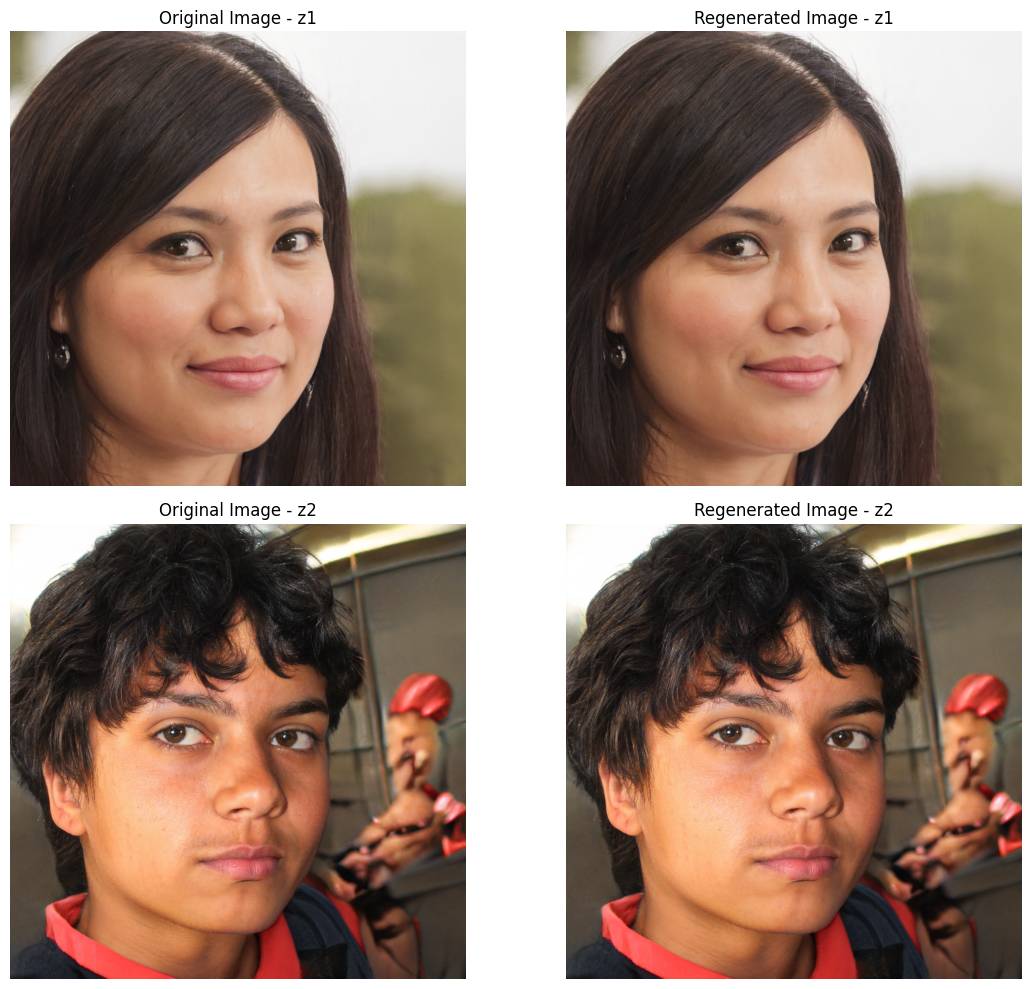

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Original Image - z1")

plt.subplot(2, 2, 2)
plt.imshow(regenerated_img1)
plt.axis("off")
plt.title("Regenerated Image - z1")

plt.subplot(2, 2, 3)
plt.imshow(img2)
plt.axis("off")
plt.title("Original Image - z2")

plt.subplot(2, 2, 4)
plt.imshow(regenerated_img2)
plt.axis("off")
plt.title("Regenerated Image - z2")

plt.tight_layout()
plt.show()

## **Step 16: Calculate Image Difference**

Mean Squared Error (MSE) is used to measure the difference between the original and regenerated images.

The formula is:

\[
MSE = \frac{1}{N}\sum_{i=1}^{N}(I_i-R_i)^2
\]

where:

- `I` = original image
- `R` = regenerated image
- `N` = total number of pixels

A value close to zero indicates that the images are almost identical.

In [ ]:
mse1 = np.mean(
    (img1.astype(np.float32) -
     regenerated_img1.astype(np.float32)) ** 2
)

mse2 = np.mean(
    (img2.astype(np.float32) -
     regenerated_img2.astype(np.float32)) ** 2
)

print("MSE between original and regenerated Image 1:", mse1)
print("MSE between original and regenerated Image 2:", mse2)

MSE between original and regenerated Image 1: 0.015571594
MSE between original and regenerated Image 2: 0.020163536


In [ ]:
regen1_path = os.path.join(
    output_dir,
    "regenerated_image_z1.png"
)

regen2_path = os.path.join(
    output_dir,
    "regenerated_image_z2.png"
)

Image.fromarray(regenerated_img1).save(regen1_path)
Image.fromarray(regenerated_img2).save(regen2_path)

print("Regenerated images saved.")

Regenerated images saved.


## **Step 17: Compare the Two Generated Images**

The two original latent vectors `z1` and `z2` represent different points in the latent space.

Therefore, their generated images have different visual characteristics.

The differences can include:

- Facial structure
- Face shape
- Hair
- Skin appearance
- Head orientation
- Facial expression
- Background
- Lighting
- Age-related appearance
- Other visual characteristics

The important observation is that these characteristics can change gradually when moving through the latent space.

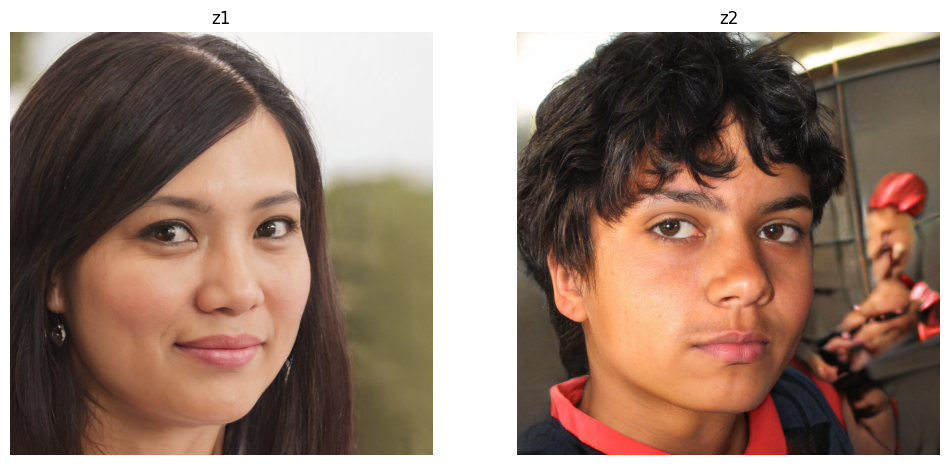

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("z1")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off")
plt.title("z2")

plt.show()

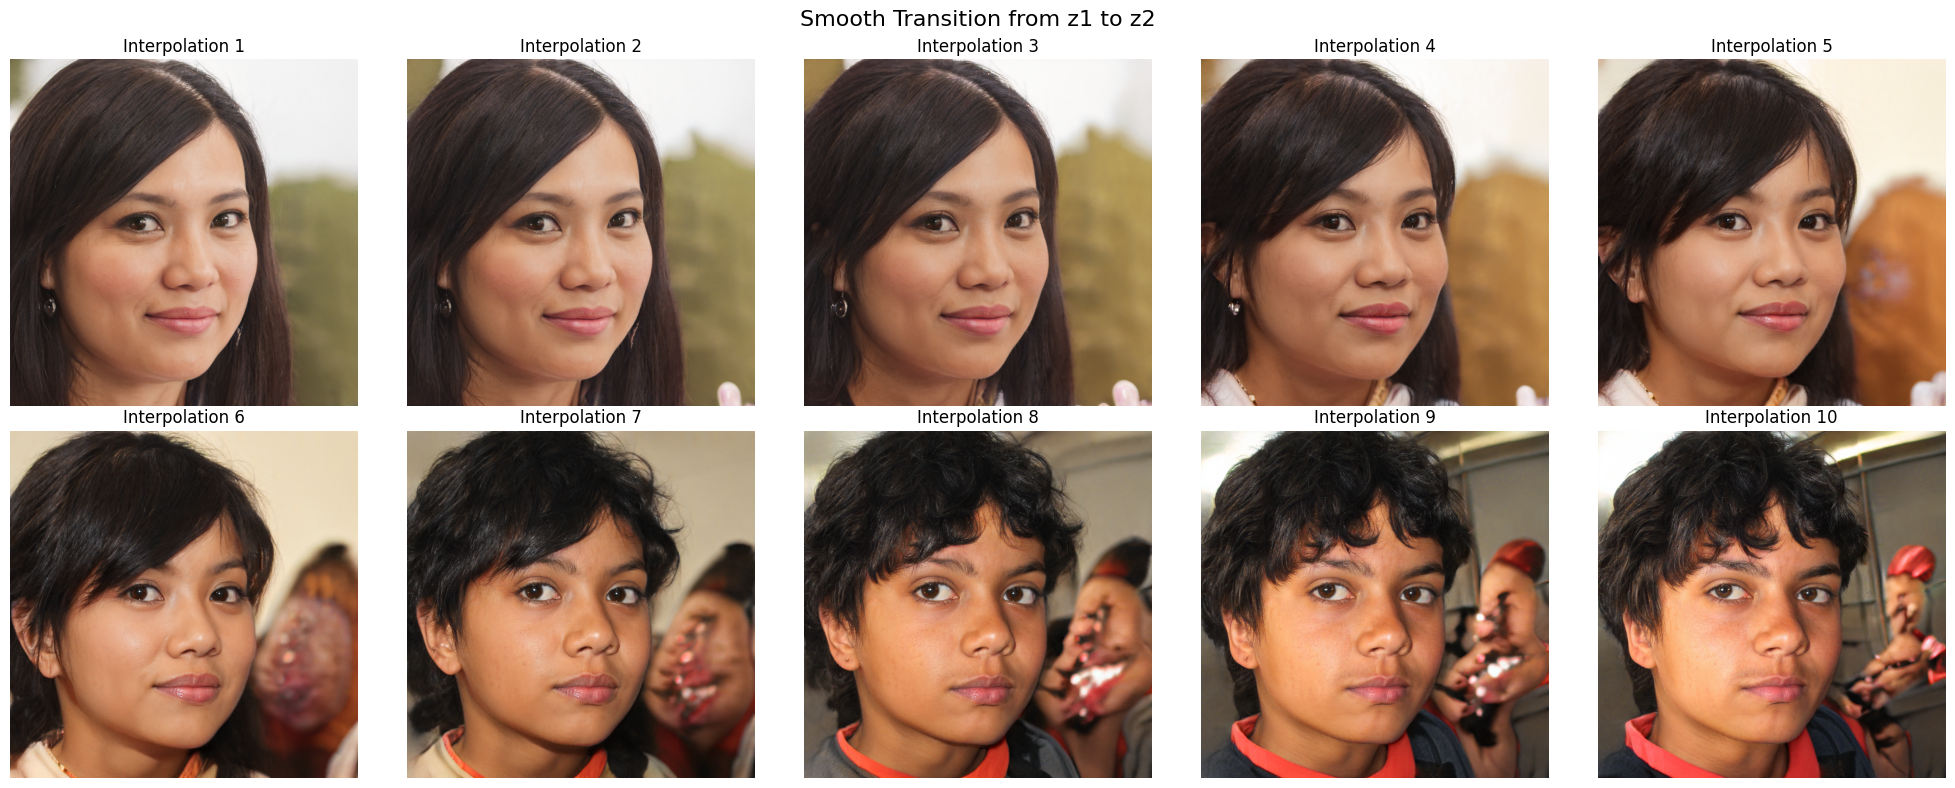

In [ ]:
plt.figure(figsize=(20, 8))

for i, image in enumerate(interpolated_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Interpolation {i+1}")

plt.suptitle(
    "Smooth Transition from z1 to z2",
    fontsize=16
)

plt.tight_layout()
plt.show()

## **Observation**

The interpolation experiment shows that the generated image changes gradually when the latent vector moves from `z1` to `z2`.

The first image corresponds to `z1`, while the final image corresponds to `z2`.

The intermediate latent vectors produce intermediate visual characteristics.

The transition is not a sudden jump from one face to another. Instead, StyleGAN produces a smooth transformation in which several visual properties change progressively.

## **Changes Observed During Latent Interpolation**

During the interpolation between `z1` and `z2`, several visual characteristics can change gradually.

### **1. Face Shape**

The shape and structure of the generated face may gradually change from the characteristics of the first face to those of the second face.

### **2. Hair**

Hair length, hairstyle, hairline, and other hair characteristics may change during interpolation.

### **3. Facial Expression**

The expression of the generated person can gradually change, such as changes around the eyes, eyebrows, and mouth.

### **4. Head Orientation**

The viewing angle or orientation of the generated face can change smoothly.

### **5. Skin Appearance**

Skin texture, tone, and other appearance-related characteristics may change.

### **6. Background**

The background surrounding the face can also change gradually.

### **7. Lighting**

The lighting conditions and brightness of the generated image may change.

### **8. Facial Features**

Features such as the eyes, nose, eyebrows, and mouth can gradually transform.

### **Overall Observation**

The experiment demonstrates that StyleGAN has a structured latent space. Moving between two points in this space can produce smooth and meaningful changes in the generated image.

# **Conclusion**

In this experiment, a pretrained StyleGAN2-ADA model was successfully loaded and used to generate synthetic face images.

Two random latent vectors, `z1` and `z2`, were generated and converted into two different images.

Linear interpolation was then performed between `z1` and `z2`. Approximately 10 intermediate latent vectors were generated, and each vector was converted into an image.

The resulting image strip demonstrated a smooth transition between the two generated faces. During interpolation, characteristics such as face shape, hair, facial expression, head orientation, background, lighting, and facial features changed gradually.

The same latent vectors were also used to generate the original images again. The regenerated images were compared with the original images using visual comparison and Mean Squared Error. Since the same latent vectors and deterministic noise settings were used, the regenerated images were almost identical to the originals.

Therefore, the experiment demonstrates how StyleGAN's latent space can represent meaningful visual features and how moving through this space enables smooth and controlled image transformations.